<a href="https://colab.research.google.com/github/Asm2910/multimodal_rag/blob/main/MultiModalRAG_dataset_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q datasets requests pymupdf arxiv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python build_dataset_hf.py --keyword "vision transformer" --n 100 --out /content/drive/MyDrive/rag_data

README.md: 100% 2.32k/2.32k [00:00<00:00, 6.05MB/s]
dataset columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']
found 100 matching ids
downloaded 2602.11323
downloaded 2602.15783
downloaded 2609.27735
downloaded 2609.29193
downloaded 2609.29433
downloaded 2609.29650
downloaded 2609.29785
downloaded 2409.13568
downloaded 2604.16743
downloaded 2609.12825
downloaded 2609.27511
downloaded 2609.27793
downloaded 2609.27988
downloaded 2609.28187
downloaded 2609.28283
downloaded 2512.22760
downloaded 2605.00915
failed 2606.22892
downloaded 2609.24424
downloaded 2609.25978
downloaded 2609.26512
downloaded 2506.08641
downloaded 2506.11784
downloaded 2508.03749
downloaded 2606.08721
downloaded 2606.24525
downloaded 2609.22105
downloaded 2609.22271
downloaded 2609.22506
downloaded 2609.22604
downloaded 2609.23019
downloaded 2609.23397
downloaded 2609.24064
downloaded 2609.2

4777 {'doc_id': '2311.08493', 'page': 1, 'type': 'text', 'content': 'Performance of Machine Learning Classification\nin Sonomammogram Images Using BI-RADS\nMalitha Gunawardhana\nAuckland Bioengineering Institute\nUniversity of Auckland\nNew Zealand\nNorbert Zolek\nInstitute of Fundamental Technological Research\nPolish Academy of Sciences\nPoland\nAbstract—This research aims to investigate the classifi-\ncation accuracy of various state-of-the-art image classifi-\ncation models across different categories of breast ultra-\nsound images, as defined by the Breast Imaging Reporting\nand Data System (BI-RADS). The experiments used 2,945\nsonomammogram images for training and 936 images for\nvalidation from a cohort of 1,540 patients, with zero patient\noverlap between the two sets. In order to conduct a thorough\nanalysis, we evaluated six classification architecture families,\ncomprising seven model variants: VGG19 [1], ResNet50\n[2], GoogLeNet [3], ConvNeXt [4], EfficientNet-V2 [5], and\

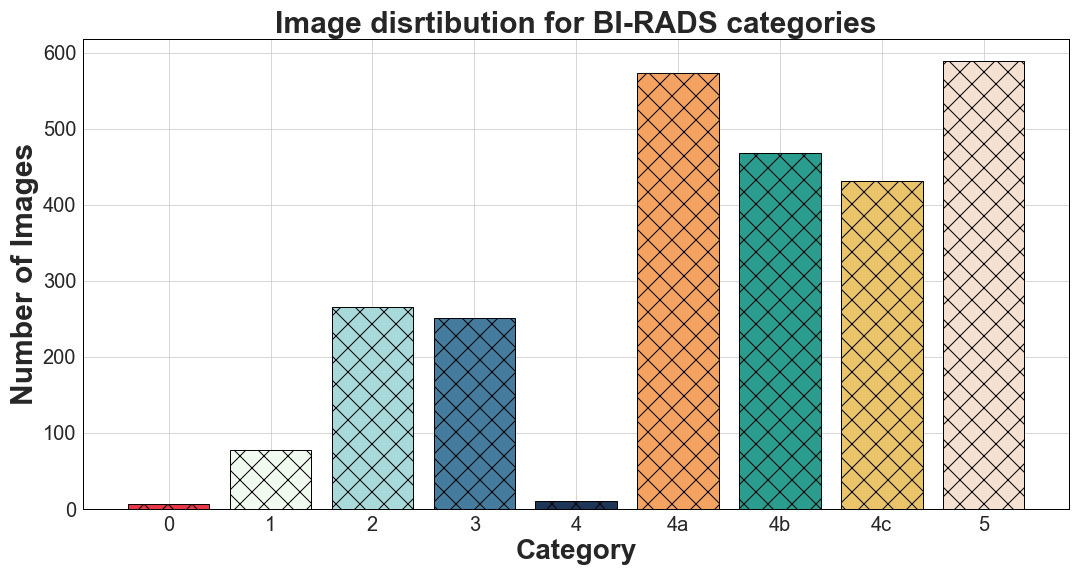

In [ ]:
import json
m = json.load(open("/content/drive/MyDrive/rag_data/manifest.json"))
print(len(m), m[0])

from IPython.display import Image, display
imgs = [r for r in m if r["type"] != "text"]
display(Image(imgs[0]["path"]))

In [ ]:
from collections import Counter
print(Counter(r["type"] for r in m))
print("papers:", len({r["doc_id"] for r in m}))

Counter({'image': 2723, 'text': 1897, 'chart_page': 157})
papers: 97


In [ ]:
!cd /content/drive/MyDrive && zip -qr /content/rag_data.zip rag_data
from google.colab import files
files.download("/content/rag_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image
from collections import defaultdict

MAX_PER_PAPER = 10
MIN_PIXELS = 300 * 300

by_doc = defaultdict(list)
for r in m:
    if r["type"] == "text":
        continue
    with Image.open(r["path"]) as im:
        w, h = im.size
    if r["type"] == "image" and w * h < MIN_PIXELS:
        continue
    r["pixels"] = w * h
    by_doc[r["doc_id"]].append(r)

selected = []
for doc, recs in by_doc.items():
    charts = [x for x in recs if x["type"] == "chart_page"]
    images = sorted((x for x in recs if x["type"] == "image"),
                    key=lambda x: -x["pixels"])
    selected += charts + images[:max(0, MAX_PER_PAPER - len(charts))]

print("vision calls needed:", len(selected))

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (114843746 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


vision calls needed: 717


TEXT -> 2609.12825 page 2 | chars: 2567
2 M. B. Çelik et al. size inherently limits the ability to capture long-range global context, which
is often crucial for identifying subtle pathological patterns across high-resolution scans [10].
Vision Transformers (ViTs) [12] and their hierarchical variants like Swin Transformers [11] overcame
this by utilizing self-attention for global spa- tial modeling. Yet, the quadratic computational
complexity of attention mech- anisms remains a significant bottleneck for real-time clinical
deployment. To address this, State Space Models (SSMs) like Mamba have emerged as efficient
alternatives, offering linear-complexity modeling of long-range context [7,8]. Despite these
advances, a persistent challenge in medical imaging is the entanglement of pathological features
with visually similar anatomic


IMAGE -> 2609.17152 page 12 | /content/drive/MyDrive/rag_data/images/2609.17152_p12_img0.png


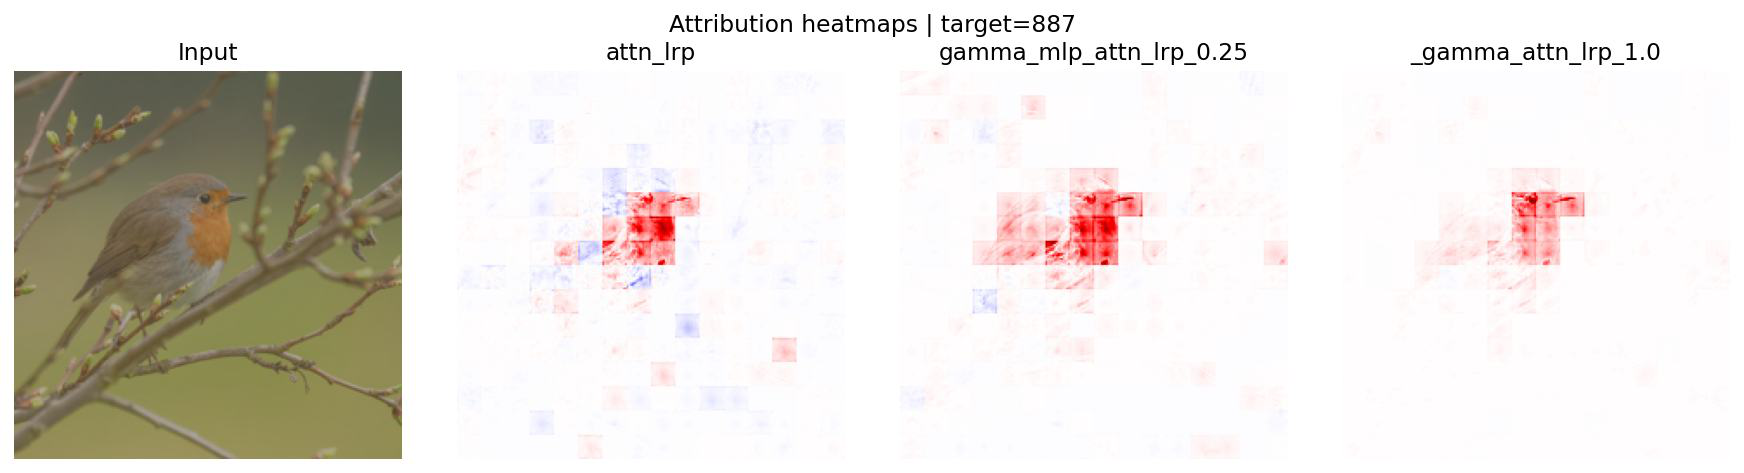

CHART PAGE -> 2609.13232 page 4 | /content/drive/MyDrive/rag_data/images/2609.13232_p4_render.png


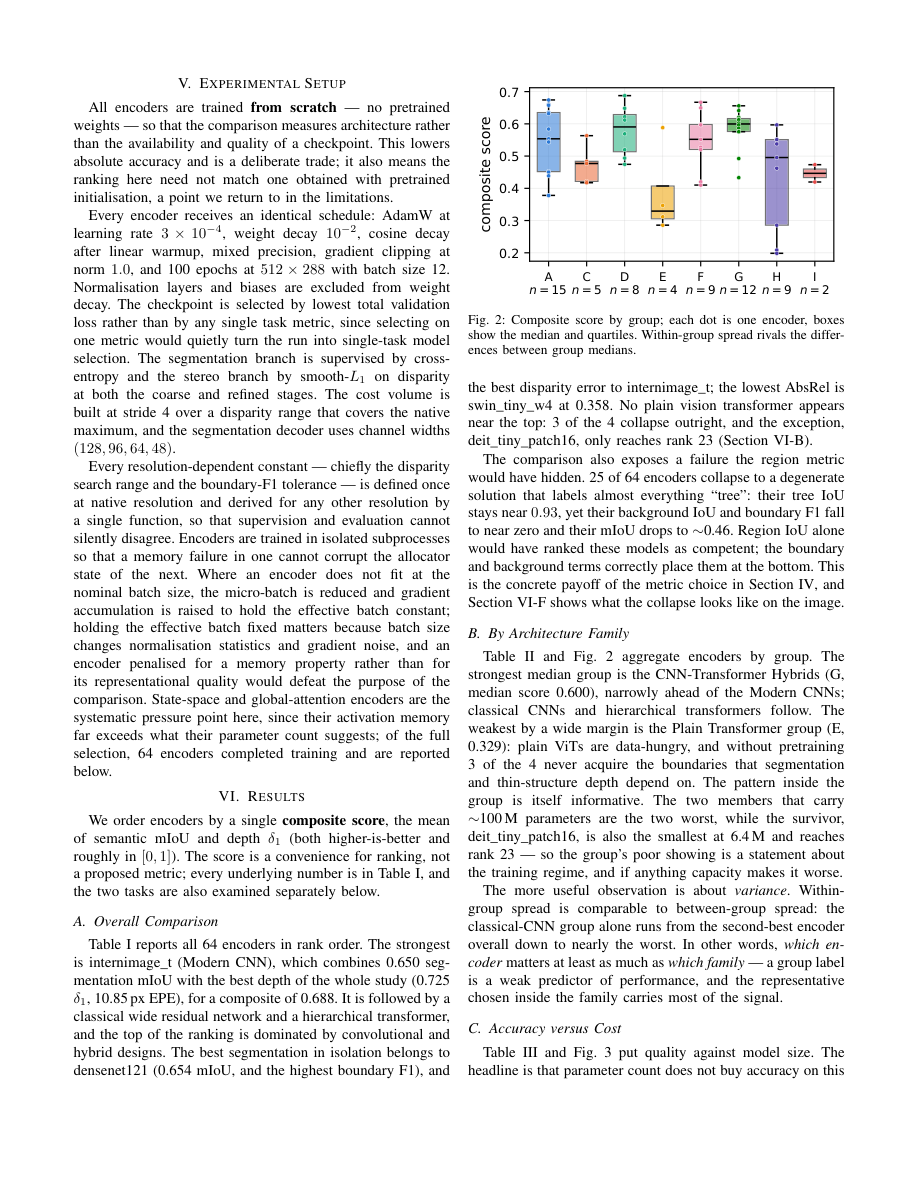

In [ ]:
import json, random, textwrap
from IPython.display import Image, display

m = json.load(open("/content/drive/MyDrive/rag_data/manifest.json"))

texts  = [r for r in m if r["type"] == "text"]
images = [r for r in m if r["type"] == "image"]
charts = [r for r in m if r["type"] == "chart_page"]

# 1. Random text record
t = random.choice(texts)
print("TEXT ->", t["doc_id"], "page", t["page"], "| chars:", len(t["content"]))
print(textwrap.fill(t["content"][:800], 100))
print("\n" + "=" * 100 + "\n")

# 2. Random embedded image
i = random.choice(images)
print("IMAGE ->", i["doc_id"], "page", i["page"], "|", i["path"])
display(Image(i["path"], width=500))

# 3. Random chart page
c = random.choice(charts)
print("CHART PAGE ->", c["doc_id"], "page", c["page"], "|", c["path"])
display(Image(c["path"], width=500))

In [ ]:
import random
i = random.choice([r for r in m if r["type"] == "image"])
print(i)

{'doc_id': '2502.16697', 'page': 39, 'type': 'image', 'path': '/content/drive/MyDrive/rag_data/images/2502.16697_p39_img18.png'}
